In [1]:
from nltk.corpus import stopwords
from gensim.models import Word2Vec
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.corpus import wordnet
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.model_selection import GridSearchCV
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
import joblib


In [2]:
df_train = pd.read_csv("data\Train.csv")
df_valid = pd.read_csv("data\Valid.csv")
df_test = pd.read_csv("data\Test.csv")
#df_combined = pd.concat([df_train, df_valid,df_test], ignore_index=True)
#X = df_combined["text"]
#y = df_combined["label"]
#X_train, X_test, y_train, y_test = train_test_split(
 #   X, y, test_size=0.2, random_state=42)

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()
vectorizer = CountVectorizer()

In [3]:
def lemmatize_word(word):
    tag = pos_tag([word])[0][1][0].upper()
    tag_dict = {"J": wordnet.ADJ,
                "N": wordnet.NOUN,
                "V": wordnet.VERB,
                "R": wordnet.ADV}
    wordnet_pos = tag_dict.get(tag, wordnet.NOUN)
    return lemmatizer.lemmatize(word, pos=wordnet_pos)

In [4]:
def preprocess(text):
    tokens = word_tokenize(text.lower())
    tokens = [lemmatize_word(w) for w in tokens if w.isalpha() and w not in stop_words]
    return " ".join(tokens)

In [5]:
X_train = df_train["text"].apply(preprocess)
X_valid = df_valid["text"].apply(preprocess)
X_test= df_test["text"].apply(preprocess)

In [6]:
len(df_valid["text"])/(len(df_train["text"])+len(df_valid["text"])+len(df_test["text"]))

0.1

In [7]:
X_counts = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_valid) 



CountVectorizer_models = {
    "Logistic Regression": (LogisticRegression(max_iter=1000), {"C": [0.1, 1, 10]}),
    "Naive Bayes": (MultinomialNB(), {"alpha": [0.5, 1, 2]}),
    "DecisionTreeClassifier": (DecisionTreeClassifier(random_state=42), {'max_depth': [100,150,200,250,300],'min_samples_split': [2, 5, 10,20,50,100]})
}


for name, (model, params) in CountVectorizer_models.items():
    grid1 = GridSearchCV(model, params, cv=5, n_jobs=-1) 
    grid1.fit(X_counts, df_train["label"])
    y_pred = grid1.predict(X_test_vec)
    print(f"#{name}# ")
    print("Best Params : m", grid1.best_params_)
    print(classification_report(df_valid["label"], y_pred))

#Logistic Regression# 
Best Params : m {'C': 0.1}
              precision    recall  f1-score   support

           0       0.89      0.88      0.89      2486
           1       0.88      0.90      0.89      2514

    accuracy                           0.89      5000
   macro avg       0.89      0.89      0.89      5000
weighted avg       0.89      0.89      0.89      5000

#Naive Bayes# 
Best Params : m {'alpha': 1}
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      2486
           1       0.87      0.83      0.85      2514

    accuracy                           0.85      5000
   macro avg       0.85      0.85      0.85      5000
weighted avg       0.85      0.85      0.85      5000

#DecisionTreeClassifier# 
Best Params : m {'max_depth': 100, 'min_samples_split': 100}
              precision    recall  f1-score   support

           0       0.73      0.71      0.72      2486
           1       0.72      0.74      0.73      2514

 

In [8]:
vectorizer_Tfid = TfidfVectorizer(max_features=30000,ngram_range=(1,2))  
x_train = vectorizer_Tfid.fit_transform(X_train)
x_valid  = vectorizer_Tfid.transform(X_valid)

In [9]:
x_valid.shape[0]

5000

In [10]:
tfidf_models = {
    "Logistic Regression": (LogisticRegression(max_iter=1000), {"C": [0.1, 1, 10]}),
    "Naive Bayes": (MultinomialNB(), {"alpha": [0.5, 1, 2]}),
    "DecisionTreeClassifier": (DecisionTreeClassifier(random_state=42), {'max_depth': [100,150,200,250,300],'min_samples_split': [2, 5, 10,20,50,100]})
}



for name, (model, params) in tfidf_models.items():
    grid2 = GridSearchCV(model, params, cv=5, n_jobs=-1) 
    grid2.fit(x_train, df_train["label"])
    y_pred = grid2.predict(x_valid)
    print(f"#{name}# ")
    print("Best Params : m", grid2.best_params_)
    print(classification_report(df_valid["label"], y_pred))

#Logistic Regression# 
Best Params : m {'C': 10}
              precision    recall  f1-score   support

           0       0.90      0.88      0.89      2486
           1       0.89      0.90      0.90      2514

    accuracy                           0.89      5000
   macro avg       0.89      0.89      0.89      5000
weighted avg       0.89      0.89      0.89      5000

#Naive Bayes# 
Best Params : m {'alpha': 0.5}
              precision    recall  f1-score   support

           0       0.88      0.86      0.87      2486
           1       0.86      0.88      0.87      2514

    accuracy                           0.87      5000
   macro avg       0.87      0.87      0.87      5000
weighted avg       0.87      0.87      0.87      5000

#DecisionTreeClassifier# 
Best Params : m {'max_depth': 100, 'min_samples_split': 100}
              precision    recall  f1-score   support

           0       0.73      0.74      0.73      2486
           1       0.74      0.73      0.73      2514



In [11]:
df_train_tokens = [word_tokenize(text.lower()) for text in X_train]
w2v = Word2Vec(df_train_tokens, vector_size=500, window=10, min_count=3, workers=10)

def document_vector(sentence):
     tokens = word_tokenize(sentence.lower())
     vectors = [w2v.wv[w] for w in tokens if w in w2v.wv]
     if len(vectors) == 0:
          return np.zeros(500) 
     return np.mean(vectors, axis=0)
X__train = np.array([document_vector(sentence) for sentence in X_train])
X__val = np.array([document_vector(sentence) for sentence in X_valid])

In [12]:
w2v_models = {
    "Logistic Regression": (LogisticRegression(max_iter=1000), {"C": [0.1, 1, 10]}),
    "DecisionTreeClassifier": (DecisionTreeClassifier(random_state=42), {'max_depth': [100,150,200,250,300],'min_samples_split': [2, 5, 10,20,50,100]})}



for name, (model, params) in w2v_models.items():
    grid3 = GridSearchCV(model, params, cv=5, n_jobs=-1) 
    grid3.fit(X__train, df_train["label"])
    y_pred = grid3.predict(X__val)
    print(f"#{name}# ")
    print("Best Params : m", grid3.best_params_)
    print(classification_report(df_valid["label"], y_pred))

#Logistic Regression# 
Best Params : m {'C': 10}
              precision    recall  f1-score   support

           0       0.86      0.85      0.85      2486
           1       0.85      0.87      0.86      2514

    accuracy                           0.86      5000
   macro avg       0.86      0.86      0.86      5000
weighted avg       0.86      0.86      0.86      5000

#DecisionTreeClassifier# 
Best Params : m {'max_depth': 100, 'min_samples_split': 100}
              precision    recall  f1-score   support

           0       0.77      0.77      0.77      2486
           1       0.77      0.77      0.77      2514

    accuracy                           0.77      5000
   macro avg       0.77      0.77      0.77      5000
weighted avg       0.77      0.77      0.77      5000



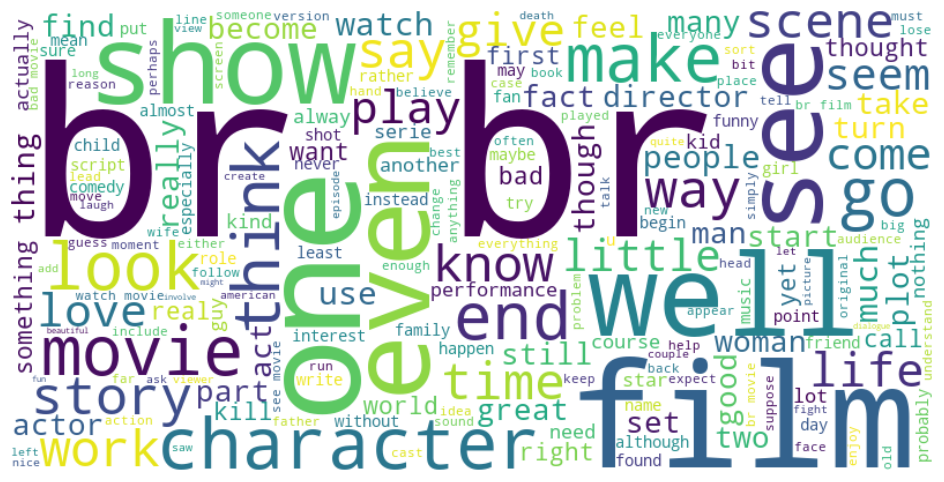

In [13]:
all_text = " ".join(X_train)  

processed_text = preprocess(all_text)

wc = WordCloud(width=800, height=400, background_color='white').generate(processed_text)

plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

In [14]:
test  = vectorizer_Tfid.transform(X_test)
best_lr = grid2.best_estimator_

y_pred=best_lr.predict(test)
print(best_lr)
print(classification_report(df_test["label"], y_pred))

DecisionTreeClassifier(max_depth=100, min_samples_split=100, random_state=42)
              precision    recall  f1-score   support

           0       0.73      0.75      0.74      2495
           1       0.74      0.72      0.73      2505

    accuracy                           0.73      5000
   macro avg       0.73      0.73      0.73      5000
weighted avg       0.73      0.73      0.73      5000



In [ ]:
joblib.dump(best_lr, "best_model.pkl")

joblib.dump(vectorizer_Tfid, "tfidf_vectorizer.pkl")


['tfidf_vectorizer.pkl']